# Is the Markovian (state-only) model actually needed, or would an explicit
# age-dependent hazard fit just as well?

## Context

`pdf/manuscript_perspective.pdf` ("Old worms, new tricks: dynamical
instability explains late-life rejuvenation in C. elegans") argues that
late-life DAF-2 depletion still extends lifespan because the underlying
Langevin dynamics are **Markovian**: the rate of change of the collective
state `z` depends only on `z`'s current value, not on elapsed calendar
time (Fig. 2 there shows simulated DMSO/Auxin_day_21 trajectories with
boxed insets arguing day-10 vs. day-21 dynamics "look indistinguishable").

A reviewer raised the following comment:

> "The manuscript argues that the Markov property of the Langevin
> trajectory ... explains why late-life DAF-2 degradation remains
> effective. This is the paper's most important claim, and it is currently
> supported only by visual inspection of trajectory insets in Figure 2 ...
> Visual similarity is insufficient. The authors should provide a
> quantitative comparison: at minimum, a statistical test asking whether
> an age-dependent model describes the empirical survival data
> significantly better than a Markovian one. If such a test cannot be
> performed with currently available data, that limitation should be
> stated explicitly and the claim should be moderated accordingly."

## What this notebook actually tests

**The Markov property itself is not testable by simulating the model --
it's a mathematical consequence of writing the drift/diffusion as
functions of `z` alone (no explicit `t`), true by construction for any
parameter values.** What *is* testable against real data is a narrower,
empirical question: does our state-dependent parametric family describe
the observed survival data at least as well as a comparably-simple,
purely age-dependent alternative (the classical Gompertz hazard)? That is
the comparison built below, in two parts:

1. **DMSO_day_10 (baseline, single phase).** Take our model's own fitted
   `(alpha, g, sigma)` for DMSO_day_10 directly from
   `0_auto_fit_parameters_mle.py` (not refit here). Fit a Gompertz hazard
   to the same data by maximum likelihood. Compare via AIC.
2. **DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention).** Take
   our model's own fitted two-phase parameters (phase 1 = DMSO, phase 2 =
   Auxin_day_21's post-switch fit, both from `0_auto_fit_parameters_mle.py`).
   Build a matching two-piece Gompertz model: phase 1 fixed at Part 1's
   own DMSO Gompertz fit, phase 2 fit fresh to Auxin_day_21 -- mirroring
   exactly how our own two-phase model only re-fits phase 2 at the
   intervention. Compare via AIC.

Both comparisons use the *same* discrete-time, grouped-data likelihood
construction for both model families (interval probability mass for
deaths, survival probability for censoring -- see `_neg_log_lik_from_S`
below), so the two hazard shapes are judged on equal footing.

## Why the model is Markovian -- a provable consequence, not an assumption

A stochastic process is Markovian if the distribution of its *next* step
depends only on its *current* state, not on how it got there or how much
calendar time has elapsed. Our model is `dz/dt = alpha*z + g*z^2 +
noise`, with `alpha`, `g` (`=alpha/Z`), and `sigma_sq` all *constants*
within a given phase -- the right-hand side is a function of `z` alone,
with no explicit `t` anywhere in it. **Any Ito SDE `dz = b(z)dt +
sigma(z)dW` whose drift and diffusion depend only on the state defines a
time-homogeneous Markov process, by construction.** This is why the
Markov property cannot be independently "tested" by simulating the
model -- a time-homogeneous SDE cannot fail to generate Markovian
trajectories. What data *can* test is whether this particular equation
(rather than some richer, `t`-dependent alternative) is an adequate
description of the real biology -- exactly the hazard-shape comparison
run below.

**One precise caveat about the switch.** The two-phase model changes
`(alpha, Z)` at a fixed calendar day `t_switch`, an exogenous,
deterministic event (the actual day the intervention was applied) -- not
a hidden dependence of `z`'s own evolution on its history. *Within* each
phase, conditional on which side of `t_switch` a worm is on, the
dynamics remain exactly Markovian in the sense above.

## What this comparison can and cannot establish

1. **A saturated (fully free) hazard model would not be a fair
   alternative** -- one free parameter per observed death age always
   wins against any constrained model. We do not use it here; the fair
   test is against a comparably-simple alternative with a matched
   parameter count.
2. **Neither test directly validates the trajectory-level Markov claim.**
   `z` is never directly measured -- we only ever observe population
   death/censoring times. Any test built from survival data is a test of
   the *population-level hazard shape*, not of whether an individual
   worm's future genuinely depends only on its own current state.
3. **DMSO's mortality is only observed at 8 check-day ages**, with deaths
   compressed into the last four -- coarse enough that a hazard which
   plateaus *within* one of those gaps looks identical, in this data, to
   one that never plateaus. This limits how much either test's outcome
   can be over-read as evidence for or against a real late-life plateau.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, minimize

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import kaplan_meier_curve, load_raw_survival_data
from model import km_from_fpt, simulate_fpt_and_state, simulate_two_phase

raw_data = load_raw_survival_data()
for name, d in raw_data.items():
    print(f"{name}: n={d.n_total} worms, ages {d.t.min():.0f}-{d.t.max():.0f} days")

DMSO_day_10: n=232 worms, ages 10-25 days
Auxin_day_10: n=81 worms, ages 10-42 days
Auxin_day_21: n=247 worms, ages 10-39 days


## Shared likelihood machinery

Both model families are scored with the same grouped-data log-likelihood
construction used throughout this project
(`0_auto_fit_parameters_mle.py`'s `_weighted_neg_log_lik`): each observed
death at age `t_i` contributes the model's own interval probability mass
`S(t_(i-1)) - S(t_i)` (`t_(0)=0`, `S(0)=1`); each censored worm at `t_i`
contributes the model's survival probability `S(t_i)`. The two model
families differ only in how `S` is produced -- closed-form for Gompertz,
simulated for our Langevin model -- everything else about how a
log-likelihood is built from `S` is identical, so neither model gets an
easier scoring rule than the other.

In [3]:
def _grouped_death_censor_weights(d):
    """(t_unique, death_weight, censor_weight) for one GroupedSurvivalData."""
    t_unique = np.unique(d.t)
    death_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 0)].sum() for t in t_unique])
    return t_unique, death_weight, censor_weight


def _neg_log_lik_from_S(S_at_grid, death_weight, censor_weight, floor):
    """
    Negative grouped-data log-likelihood given S already evaluated at
    `[0, t_unique...]` (so `S_at_grid[0] == 1` by construction).
    """
    S_at_grid = np.clip(S_at_grid, floor, 1.0)
    interval_mass = np.clip(S_at_grid[:-1] - S_at_grid[1:], floor, None)
    log_lik = np.sum(death_weight * np.log(interval_mass) + censor_weight * np.log(S_at_grid[1:]))
    if not np.isfinite(log_lik):
        return np.inf
    return -float(log_lik)


def aic(logL, k):
    return 2 * k - 2 * logL

### Gompertz hazard model

Classical Gompertz hazard `M(t) = M0*exp(alpha_g*t)`, with closed-form
survival `S(t) = exp(-(M0/alpha_g)*(exp(alpha_g*t) - 1))` -- an explicit
function of calendar age, no state variable or mechanism at all. The
two-piece version restarts the Gompertz clock at `t_switch` (mirroring
how our own two-phase model keeps `z` continuous but restarts its
*parameters* at the intervention): phase 2's hazard is a fresh Gompertz
curve in time-since-switch, scaled to start from phase 1's own survival
probability at `t_switch`.

In [4]:
def gompertz_survival(t, M0, alpha_g):
    t = np.asarray(t, dtype=float)
    return np.exp(-(M0 / alpha_g) * np.expm1(alpha_g * t))


def gompertz_survival_two_phase(t, M0_1, alpha_g1, M0_2, alpha_g2, t_switch):
    t = np.asarray(t, dtype=float)
    S = np.where(
        t <= t_switch,
        gompertz_survival(t, M0_1, alpha_g1),
        gompertz_survival(t_switch, M0_1, alpha_g1)
        * gompertz_survival(np.clip(t - t_switch, 0.0, None), M0_2, alpha_g2),
    )
    return S


def _fit_two_stage(objective, bounds, seed):
    """Differential-evolution global search + Nelder-Mead local polish,
    the same two-stage pattern used for every fit in this project."""
    de_result = differential_evolution(objective, bounds, seed=seed, maxiter=200, popsize=20, polish=False)
    local_result = minimize(objective, x0=de_result.x, method="Nelder-Mead", bounds=bounds,
                             options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 2000})
    best_x = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_fun = min(local_result.fun, de_result.fun)
    return best_x, best_fun


def fit_gompertz_single(d, bounds, seed=0):
    """MLE fit of (M0, alpha_g) to one condition's grouped survival data."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)

    def objective(params):
        M0, alpha_g = params
        S = gompertz_survival(np.concatenate(([0.0], t_unique)), M0, alpha_g)
        return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

    return _fit_two_stage(objective, bounds, seed)


def fit_gompertz_two_phase(d, fixed_phase1, t_switch, bounds, seed=0):
    """MLE fit of (M0_2, alpha_g2) only; phase 1 is fixed (not fit to this
    condition's data), exactly mirroring the Langevin model's own
    phase-1-fixed-from-DMSO construction below."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    M0_1, alpha_g1 = fixed_phase1

    def objective(params2):
        M0_2, alpha_g2 = params2
        S = gompertz_survival_two_phase(
            np.concatenate(([0.0], t_unique)), M0_1, alpha_g1, M0_2, alpha_g2, t_switch,
        )
        return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

    return _fit_two_stage(objective, bounds, seed)

### Our Langevin model's own likelihood

`S` is produced by simulating `n_paths` first-passage times from the
actual model (`model.simulate_fpt_and_state`/`simulate_two_phase`, the
same `beta=1` model used everywhere else in this project) and reading
its own Kaplan-Meier curve off those simulated paths -- no closed-form
approximation, so this is correct regardless of `gamma`.

The clipping `floor` passed to `_neg_log_lik_from_S` is deliberately
`1/(d.n_total + 1)` -- the real cohort size -- **not** `1/(n_paths + 1)`.
The floor exists to reflect the real data's own statistical resolution
(you cannot distinguish an event probability finer than roughly
`1/n_total` given only `n_total` worms), which has nothing to do with
`n_paths`, an internal Monte-Carlo fidelity knob. Using `n_paths` here
would let this model's likelihood get credit/blame for tail behavior at
a resolution the real data can't actually support, and -- more
importantly -- would score it against a *different* floor than the
Gompertz functions below, silently breaking the "identical scoring rule
for both models" claim this comparison depends on.

In [5]:
def langevin_neg_log_lik_single(alpha, Z, sigma_sq, d, n_paths=20_000, dt=0.1, seed=0):
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    g = alpha / Z
    T, _, _ = simulate_fpt_and_state(
        n_paths, alpha, g, sigma_sq, Z, z0=0.0, dt=dt, t_max=t_unique[-1],
        rng=np.random.default_rng(seed),
    )
    S = km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)


def langevin_neg_log_lik_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                    n_paths=20_000, dt=0.1, seed=0):
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    T = simulate_two_phase(
        n_paths, alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, t_unique[-1], dt,
        noise1=None, noise2=None,
    )
    S = km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

## Part 1: DMSO_day_10 baseline (single phase)

Our model's `(alpha, g, sigma)` are `0_auto_fit_parameters_mle.py`'s own
Step 1 fit for DMSO_day_10 (all 3 jointly estimated from this same
data, via Monte-Carlo MLE, subject to the plausibility constraints
described there) -- **not refit here**. `k=3` for the AIC below
reflects that these 3 parameters were estimated from DMSO_day_10's data,
even though we only evaluate (not re-optimize) them in this cell.

In [6]:
a0, log_g0, sigma0 = 0.1553, -2.5439, 1.5941  # 0_auto_fit_parameters_mle.py, Step 1
g0 = 10.0 ** log_g0
Z0 = a0 / g0
sigma_sq0 = sigma0 ** 2
print(f"Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha={a0}, Z={Z0:.4g}, sigma_sq={sigma_sq0:.4g}")

d_dmso = raw_data["DMSO_day_10"]

nll_langevin1 = langevin_neg_log_lik_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
logL_langevin1 = -nll_langevin1
k_langevin1 = 3
print(f"Langevin model:  logL={logL_langevin1:.4g}  (k={k_langevin1})  AIC={aic(logL_langevin1, k_langevin1):.4g}")

bounds_gompertz1 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp1, nll_gomp1 = fit_gompertz_single(d_dmso, bounds_gompertz1, seed=0)
M0_dmso, alpha_g_dmso = popt_gomp1
logL_gomp1 = -nll_gomp1
k_gomp1 = 2
print(f"Gompertz model:  M0={M0_dmso:.4g}, alpha_g={alpha_g_dmso:.4g}   "
      f"logL={logL_gomp1:.4g}  (k={k_gomp1})  AIC={aic(logL_gomp1, k_gomp1):.4g}")

delta_aic1 = aic(logL_gomp1, k_gomp1) - aic(logL_langevin1, k_langevin1)
print(f"\ndelta_AIC (Gompertz - Langevin) = {delta_aic1:+.4g}  "
      f"({'favors Langevin' if delta_aic1 > 0 else 'favors Gompertz'}; "
      f"|delta_AIC| > 10 is conventionally read as decisive)")

Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha=0.1553, Z=54.33, sigma_sq=2.541
Langevin model:  logL=-408.1  (k=3)  AIC=822.1
Gompertz model:  M0=0.0004378, alpha_g=0.3336   logL=-342.9  (k=2)  AIC=689.8

delta_AIC (Gompertz - Langevin) = -132.3  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


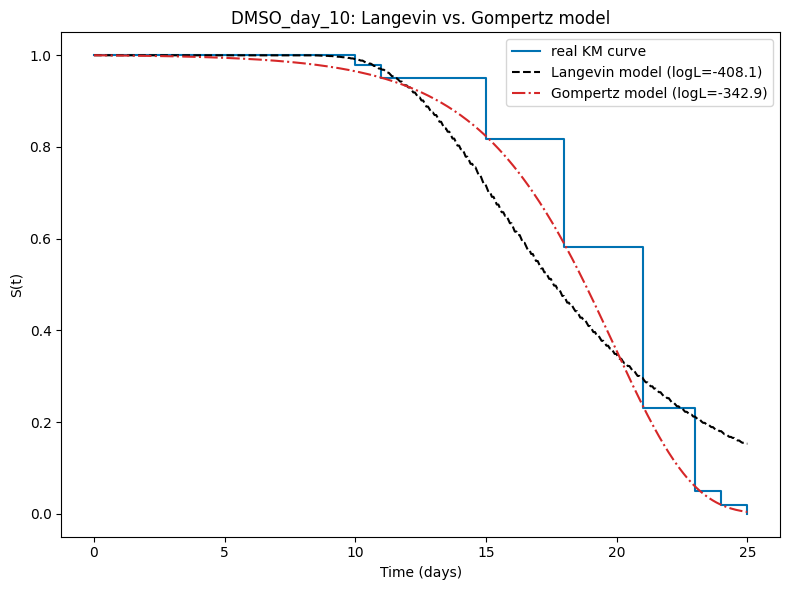

In [7]:
kmf_dmso = kaplan_meier_curve(d_dmso)
t_plot = np.linspace(0, d_dmso.t.max(), 400)
T_plot_sim1, _, _ = simulate_fpt_and_state(
    20_000, a0, g0, sigma_sq0, Z0, z0=0.0, dt=0.1, t_max=d_dmso.t.max(), rng=np.random.default_rng(1),
)
S_langevin1_plot = km_from_fpt(T_plot_sim1, t_plot, t_max=d_dmso.t.max())

fig, ax = plt.subplots(figsize=(8, 6))
kmf_dmso.plot_survival_function(ax=ax, color="#0072B2", label="real KM curve", ci_show=False)
ax.plot(t_plot, S_langevin1_plot, ls="--", color="black", label=f"Langevin model (logL={logL_langevin1:.1f})")
ax.plot(t_plot, gompertz_survival(t_plot, M0_dmso, alpha_g_dmso), ls="-.", color="tab:red",
        label=f"Gompertz model (logL={logL_gomp1:.1f})")
ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t)")
ax.set_title("DMSO_day_10: Langevin vs. Gompertz model")
ax.legend()
plt.tight_layout()
plt.show()

## Part 2: DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention)

Phase 1 is fixed at Part 1's own fits in *both* models (DMSO's own
`(alpha0, Z0)` for Langevin, `(M0_dmso, alpha_g_dmso)` for Gompertz) --
neither model gets to see Auxin_day_21's data through phase 1. Only
phase 2 is estimated from Auxin_day_21 itself: `(alpha1, Z1)` for our
model (`0_auto_fit_parameters_mle.py`'s Step 2 fit, `k=2`), `(M0_2,
alpha_g2)` for Gompertz (fit fresh here, `k=2`) -- a genuine, matched-`k`
comparison of which phase-2 hazard shape better explains what happened
after the intervention.

In [8]:
g1_scale, a1_scale = 1.0510, 0.8017  # 0_auto_fit_parameters_mle.py, Step 2
alpha1 = a0 * a1_scale
Z1 = alpha1 / (g0 ** g1_scale)
t_switch = 21.0
print(f"Langevin phase 2 (Auxin_day_21, from 0_auto_fit_parameters_mle.py): alpha={alpha1:.4g}, Z={Z1:.4g}")

d_auxin21 = raw_data["Auxin_day_21"]

nll_langevin2 = langevin_neg_log_lik_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
logL_langevin2 = -nll_langevin2
k_langevin2 = 2
print(f"Langevin model:  logL={logL_langevin2:.4g}  (k={k_langevin2}, phase 1 fixed)  "
      f"AIC={aic(logL_langevin2, k_langevin2):.4g}")

bounds_gompertz2 = [(1e-6, 2.0), (1e-3, 2.0)]
popt_gomp2, nll_gomp2 = fit_gompertz_two_phase(
    d_auxin21, fixed_phase1=(M0_dmso, alpha_g_dmso), t_switch=t_switch, bounds=bounds_gompertz2, seed=0,
)
M0_2, alpha_g2 = popt_gomp2
logL_gomp2 = -nll_gomp2
k_gomp2 = 2
print(f"Gompertz model:  M0_2={M0_2:.4g}, alpha_g2={alpha_g2:.4g}   "
      f"logL={logL_gomp2:.4g}  (k={k_gomp2}, phase 1 fixed at DMSO fit)  "
      f"AIC={aic(logL_gomp2, k_gomp2):.4g}")

delta_aic2 = aic(logL_gomp2, k_gomp2) - aic(logL_langevin2, k_langevin2)
print(f"\ndelta_AIC (Gompertz - Langevin) = {delta_aic2:+.4g}  "
      f"({'favors Langevin' if delta_aic2 > 0 else 'favors Gompertz'}; "
      f"|delta_AIC| > 10 is conventionally read as decisive)")

Langevin phase 2 (Auxin_day_21, from 0_auto_fit_parameters_mle.py): alpha=0.1245, Z=58.72
Langevin model:  logL=-457.6  (k=2, phase 1 fixed)  AIC=919.1
Gompertz model:  M0_2=0.06743, alpha_g2=0.1427   logL=-438.7  (k=2, phase 1 fixed at DMSO fit)  AIC=881.4

delta_AIC (Gompertz - Langevin) = -37.69  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


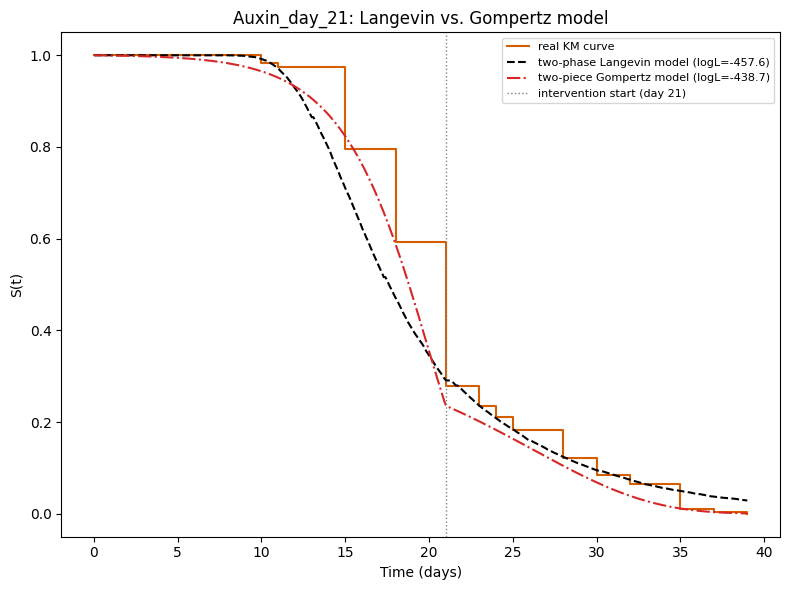

In [9]:
kmf_auxin21 = kaplan_meier_curve(d_auxin21)
t_plot21 = np.linspace(0, d_auxin21.t.max(), 400)
T_plot_sim2 = simulate_two_phase(
    20_000, a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21.t.max(), dt=0.1,
)
S_langevin2_plot = km_from_fpt(T_plot_sim2, t_plot21, t_max=d_auxin21.t.max())

fig, ax = plt.subplots(figsize=(8, 6))
kmf_auxin21.plot_survival_function(ax=ax, color="#D55E00", label="real KM curve", ci_show=False)
ax.plot(t_plot21, S_langevin2_plot, ls="--", color="black", label=f"two-phase Langevin model (logL={logL_langevin2:.1f})")
ax.plot(t_plot21, gompertz_survival_two_phase(t_plot21, M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch),
        ls="-.", color="tab:red", label=f"two-piece Gompertz model (logL={logL_gomp2:.1f})")
ax.axvline(t_switch, color="gray", lw=1, ls=":", label="intervention start (day 21)")
ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t)")
ax.set_title("Auxin_day_21: Langevin vs. Gompertz model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

Report both `delta_AIC` values above plainly, whichever way they land:
a per-condition result, not a single verdict on the model. Whichever
model wins for DMSO_day_10 alone need not also win for Auxin_day_21 --
they are testing the phase-2 hazard shape given an *identical*,
data-fixed phase-1 inheritance in both models, which is a different
question from Part 1's single-phase comparison. Either way, per the
limitations noted at the top: this only ever tests the *population-level
hazard shape* against calendar age, not the trajectory-level Markov
claim itself (`z` is never directly measured), and DMSO's coarse 8
check-day resolution limits how confidently either outcome can be read
as evidence for or against a real late-life mortality plateau.

## Manuscript-ready outputs (Supplementary Note 2)

Renders the figure and table referenced by
`notebooks/notes/supplementary_note2_model_comparison.tex`, using the
manuscript's own plotting style (`1_pub_figures.py`'s rcParams).

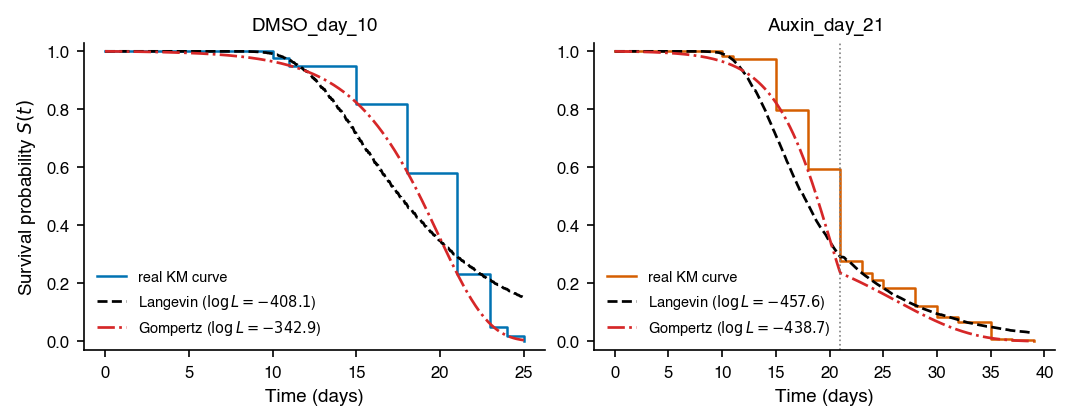

In [14]:
NOTES_DIR = NOTEBOOK_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
})
cm = 1 / 2.54

fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(18 * cm, 7 * cm))

axes_s2[0].step(kmf_dmso.survival_function_.index, kmf_dmso.survival_function_.iloc[:, 0],
                where="post", color="#0072B2", lw=1.2, label="real KM curve")
axes_s2[0].plot(t_plot, S_langevin1_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin1:.1f}$)")
axes_s2[0].plot(t_plot, gompertz_survival(t_plot, M0_dmso, alpha_g_dmso), ls="-.", color="tab:red", lw=1.3,
                 label=rf"Gompertz ($\log L={logL_gomp1:.1f}$)")
axes_s2[0].set_title("DMSO$\\_$day$\\_$10")

axes_s2[1].step(kmf_auxin21.survival_function_.index, kmf_auxin21.survival_function_.iloc[:, 0],
                where="post", color="#D55E00", lw=1.2, label="real KM curve")
axes_s2[1].plot(t_plot21, S_langevin2_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin2:.1f}$)")
axes_s2[1].plot(t_plot21, gompertz_survival_two_phase(t_plot21, M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch),
                 ls="-.", color="tab:red", lw=1.3, label=rf"Gompertz ($\log L={logL_gomp2:.1f}$)")
axes_s2[1].axvline(t_switch, color="gray", lw=0.8, ls=":")
axes_s2[1].set_title("Auxin$\\_$day$\\_$21")

for ax in axes_s2:
    ax.set_xlabel("Time (days)")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="lower left")
axes_s2[0].set_ylabel("Survival probability $S(t)$")

fig_s2.tight_layout(pad=0.6)
fig_s2.savefig(NOTES_DIR / "supp_note2_fig.png", bbox_inches="tight", dpi=600)
plt.show()

In [11]:
supp2_rows = [
    {"Condition": "DMSO\\_day\\_10", "Model": "Langevin (this work)", "k": k_langevin1,
     "logL": logL_langevin1, "AIC": aic(logL_langevin1, k_langevin1)},
    {"Condition": "DMSO\\_day\\_10", "Model": "Gompertz", "k": k_gomp1,
     "logL": logL_gomp1, "AIC": aic(logL_gomp1, k_gomp1)},
    {"Condition": "Auxin\\_day\\_21", "Model": "Langevin (this work)", "k": k_langevin2,
     "logL": logL_langevin2, "AIC": aic(logL_langevin2, k_langevin2)},
    {"Condition": "Auxin\\_day\\_21", "Model": "Gompertz", "k": k_gomp2,
     "logL": logL_gomp2, "AIC": aic(logL_gomp2, k_gomp2)},
]
supp2_table = pd.DataFrame(supp2_rows).rename(columns={
    "logL": r"$\log L$", "AIC": "AIC", "k": "$k$",
})
latex_body2 = supp2_table.to_latex(index=False, escape=False, float_format="%.1f",
                                    column_format="llrrr")
latex_table2 = (
    "% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.\n"
    "\\begin{table}[htbp]\n\\centering\n"
    + latex_body2
    + "\\caption{Grouped-data maximum-likelihood fit of our Langevin model "
      "(parameters from \\texttt{0\\_auto\\_fit\\_parameters\\_mle.py}, not "
      "refit here) versus a matched-complexity Gompertz hazard, per "
      "condition. Phase 1 is fixed at the DMSO\\_day\\_10 fit in both "
      "Auxin\\_day\\_21 models, so only phase-2 parameters "
      "($k=2$ each) are estimated from that condition's own data. "
      r"$\Delta\mathrm{AIC} = \mathrm{AIC}_\mathrm{Gompertz} - "
      r"\mathrm{AIC}_\mathrm{Langevin} = " + f"{delta_aic1:+.1f}"
      r"$ (DMSO\_day\_10), $" + f"{delta_aic2:+.1f}"
      r"$ (Auxin\_day\_21); negative values favor Gompertz.}"
      "\n\\label{tab:supp_note2_model_comparison}\n\\end{table}\n"
)
(NOTES_DIR / "supp_note2_table.tex").write_text(latex_table2)
print(latex_table2)

% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.
\begin{table}[htbp]
\centering
\begin{tabular}{llrrr}
\toprule
Condition & Model & $k$ & $\log L$ & AIC \\
\midrule
DMSO\_day\_10 & Langevin (this work) & 3 & -408.1 & 822.1 \\
DMSO\_day\_10 & Gompertz & 2 & -342.9 & 689.8 \\
Auxin\_day\_21 & Langevin (this work) & 2 & -457.6 & 919.1 \\
Auxin\_day\_21 & Gompertz & 2 & -438.7 & 881.4 \\
\bottomrule
\end{tabular}
\caption{Grouped-data maximum-likelihood fit of our Langevin model (parameters from \texttt{0\_auto\_fit\_parameters\_mle.py}, not refit here) versus a matched-complexity Gompertz hazard, per condition. Phase 1 is fixed at the DMSO\_day\_10 fit in both Auxin\_day\_21 models, so only phase-2 parameters ($k=2$ each) are estimated from that condition's own data. $\Delta\mathrm{AIC} = \mathrm{AIC}_\mathrm{Gompertz} - \mathrm{AIC}_\mathrm{Langevin} = -132.3$ (DMSO\_day\_10), $-37.7$ (Auxin\_day\_21); negative values favor Gompertz.}
\label{tab:supp_no